<a href="https://colab.research.google.com/github/zeeshan3106/Deep-Learning/blob/main/Artificial%20Neural%20Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow
from tensorflow.keras.layers import Dense
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler


<Axes: xlabel='Year', ylabel='IT_Jobs_Placed'>

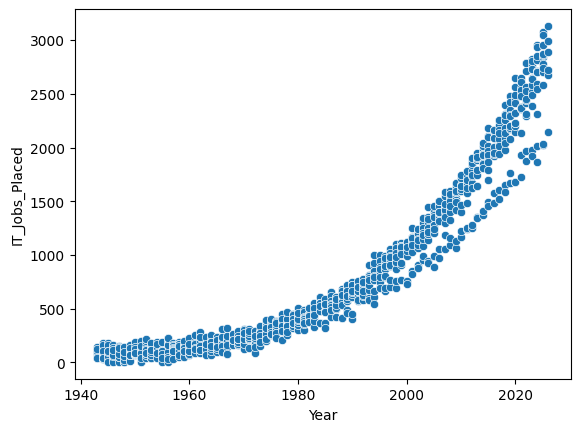

In [19]:
data = pd.read_csv("melbourne_it_jobs_placed.csv")
sns.scatterplot(x = data['Year'],y = data['IT_Jobs_Placed'])


In [41]:
callbacks = EarlyStopping(
    min_delta = 0.001,
    patience = 20,
    restore_best_weights = True

)

In [46]:
model = Sequential()
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X = data.drop("IT_Jobs_Placed",axis=1)
y = data["IT_Jobs_Placed"]
model.add(Dense(64,activation="relu", input_dim=X.shape[1]))
model.add(Dropout(0.2))
model.add(Dense(32,activation="relu", input_dim=X.shape[1]))
model.add(Dropout(0.2))
model.add(Dense(16,activation="relu", input_dim=X.shape[1]))

model.add(Dense(1,activation="linear"))
model.compile(loss="mean_absolute_error",optimizer="adam")

model.fit(X_train,y_train,epochs=100,batch_size=1, callbacks=callbacks)
from sklearn.metrics import mean_absolute_error
y_pred = model.predict(X_test)
mean_absolute_error(y_test,y_pred)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 444.3166
Epoch 2/100
 48/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 138.7764

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 165.9459
Epoch 3/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 151.5789
Epoch 4/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 155.3322
Epoch 5/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 151.8733
Epoch 6/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 141.3526
Epoch 7/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 139.7067
Epoch 8/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 140.7671
Epoch 9/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 136.7665
Epoch 10/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 134.8743
Epoch 11/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 133.4933
Epoch 12/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 134.8405
Epoch 13/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 135.5426
Epoch 14/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 122.3590
Epoch 15/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 131.0370
Epoch 16/100
800/800 ━━━━━

57.81629943847656

In [66]:
pred = model.predict(X_test)
mean_absolute_error(y_test,pred)
New={}
New['Predictions']= pd.DataFrame(pred)
New


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


array([[-0.20870698, -0.9985523 , -0.24181651],
       [-1.04773002, -0.12961629, -1.04353234],
       [-0.37651159, -1.57784297, -0.37405829],
       ...,
       [ 0.12690223,  0.44967438,  0.12184841],
       [-1.71894845,  1.60825573, -1.70474128],
       [-1.71894845, -0.12961629, -1.72953661]])